# Final test

The tuned union configuration is refit on train and validation, then scored once on the test
vintages. The test set was not used to select the features, model or parameters.

This notebook:

- Reports ROC AUC, PR AUC, Brier score and log-loss on test alongside the validation figures from
  notebook 24.
- Compares predicted and observed default rates on validation and test, including the parts of the
  score distribution used by the decision rules.
- Applies the three policies from notebook 23 to realised test outcomes and compares their
  results.

In [1]:
import json
from pathlib import Path

import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display
from sklearn.metrics import log_loss

from credit_risk.data import load_loans, load_outcomes
from credit_risk.split import out_of_time_split
from credit_risk.model import (
    build_lgbm,
    UNDERWRITER_NUMERIC, UNDERWRITER_CATEGORICAL,
    LC_VERDICT_NUMERIC, LC_VERDICT_CATEGORICAL,
)
from credit_risk.evaluate import (
    discrimination_metrics,
    reliability_data,
    expected_profit,
    breakeven_probability,
)

TARGET = "target_bad"
NUMERIC = UNDERWRITER_NUMERIC + LC_VERDICT_NUMERIC
CATEGORICAL = UNDERWRITER_CATEGORICAL + LC_VERDICT_CATEGORICAL
COLS = NUMERIC + CATEGORICAL

df = load_loans()
train, val, test = out_of_time_split(df)
train_val = pd.concat([train, val])

best = json.loads((Path("..") / "reports" / "lgbm_best_params.json").read_text())
final = build_lgbm(NUMERIC, CATEGORICAL, params=best)
final.fit(train_val[COLS], train_val[TARGET])

test = test.assign(proba=final.predict_proba(test[COLS])[:, 1])
print(f"train+val {len(train_val)}, test {len(test)}, test bad rate {test[TARGET].mean():.3f}")

train+val 529915, test 178453, test bad rate 0.155


## Out of sample

The tuned configuration reached a ROC AUC of 0.699, a PR AUC of 0.279 and a log-loss of 0.392 on
validation in notebook 24. Validation contributed to parameter selection, while the test set
provides the post-selection evaluation on later vintages. The test bad rate also differs from
validation, which affects the interpretation of PR AUC. The metrics are therefore reported for
each split without treating their difference as a direct measure of improvement.

In [2]:
metrics = discrimination_metrics(test[TARGET], test["proba"])
metrics["log_loss"] = log_loss(test[TARGET], test["proba"])
pd.Series(metrics).round(4)

roc_auc     0.7100
pr_auc      0.3037
brier       0.1214
log_loss    0.3950
dtype: float64

## Calibration

The expected-profit rule uses predicted default probabilities directly, so its decisions depend
on the relationship between predicted and observed default rates. The comparison below reports
their means on validation and test, plots both reliability curves, and checks the same
relationship by interest rate and around the two decision thresholds.

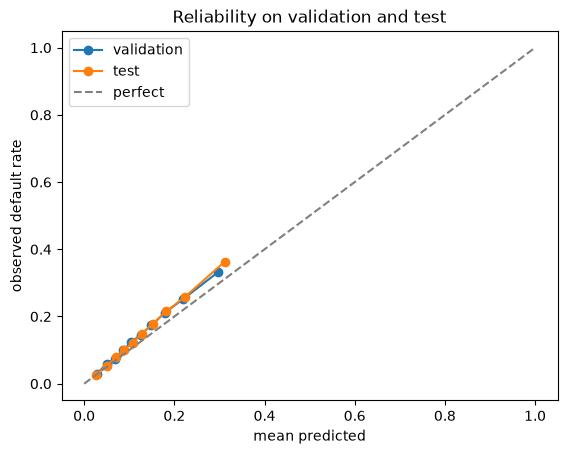

,mean_prediction,observed_rate,mean_gap,top_bin_prediction,top_bin_observed
validation,0.130608,0.150016,0.019408,0.297416,0.332558
test,0.134218,0.154640,0.020422,0.311387,0.362882


,loans,mean_prediction,observed_rate,gap
int_rate,,,,
"[0.0, 10.0)",82146,0.073790,0.079420,0.005629
"[10.0, 15.0)",69325,0.158772,0.183411,0.024639
"[15.0, 20.0)",23412,0.243331,0.293439,0.050108
"[20.0, inf)",3570,0.332305,0.416527,0.084221


In [3]:
validation_model = build_lgbm(NUMERIC, CATEGORICAL, params=best)
validation_model.fit(train[COLS], train[TARGET])
validation = val.assign(proba=validation_model.predict_proba(val[COLS])[:, 1])

calibration_rows = {}
for name, frame in [("validation", validation), ("test", test)]:
    prob_true, prob_pred = reliability_data(frame[TARGET], frame["proba"])
    calibration_rows[name] = {
        "mean_prediction": frame["proba"].mean(),
        "observed_rate": frame[TARGET].mean(),
        "mean_gap": frame[TARGET].mean() - frame["proba"].mean(),
        "top_bin_prediction": prob_pred[-1],
        "top_bin_observed": prob_true[-1],
    }
    plt.plot(prob_pred, prob_true, marker="o", label=name)

plt.plot([0, 1], [0, 1], linestyle="--", color="grey", label="perfect")
plt.xlabel("mean predicted")
plt.ylabel("observed default rate")
plt.title("Reliability on validation and test")
plt.legend()

out = Path("..") / "reports" / "reliability_test.png"
plt.savefig(out, dpi=120, bbox_inches="tight")
plt.show()

display(pd.DataFrame(calibration_rows).T)

rate_band = pd.cut(test["int_rate"], [0, 10, 15, 20, float("inf")], right=False)
rate_calibration = test.groupby(rate_band, observed=True).agg(
    loans=(TARGET, "size"),
    mean_prediction=("proba", "mean"),
    observed_rate=(TARGET, "mean"),
)
rate_calibration["gap"] = (
    rate_calibration["observed_rate"] - rate_calibration["mean_prediction"]
)
rate_calibration

## What it is worth

This section applies the three policies from notebook 23 to realised test outcomes. The single
break-even threshold is calculated from the amount-weighted average rate in train and validation,
without using test data. The results show whether the ordering of the policies on validation
carries to the test vintages.

In [4]:
outcomes = load_outcomes().drop(columns=["loan_amnt"])
scored = test.merge(outcomes, on="id")
assert len(scored) == len(test)

scored["realised_profit"] = (
    scored["total_rec_prncp"] + scored["recoveries"] + scored["total_rec_int"] - scored["loan_amnt"]
)
scored["exp_profit"] = expected_profit(scored["proba"], scored["loan_amnt"], scored["int_rate"])

r_bar = (train_val["int_rate"] * train_val["loan_amnt"]).sum() / train_val["loan_amnt"].sum()
c = breakeven_probability(r_bar)
print(f"single break-even: {c:.3f}, from an average rate of {r_bar:.1f}%")

policies = {
    "approve all": pd.Series(True, index=scored.index),
    "single break-even": scored["proba"] < c,
    "expected profit": scored["exp_profit"] > 0,
}

rows = {}
for name, approve in policies.items():
    taken = scored[approve]
    rows[name] = {
        "approved": len(taken),
        "total_profit": taken["realised_profit"].sum(),
        "profit_per_loan": taken["realised_profit"].mean(),
        "bad_rate": taken[TARGET].mean(),
    }

policy_results = pd.DataFrame(rows).T
display(policy_results)

own_cutoff = breakeven_probability(scored["int_rate"])
near_cutoff = {
    "single threshold": (scored["proba"] - c).abs() <= 0.01,
    "per-loan threshold": (scored["proba"] - own_cutoff).abs() <= 0.01,
}
decision_rows = {}
for name, mask in near_cutoff.items():
    part = scored[mask]
    decision_rows[name] = {
        "loans": len(part),
        "mean_prediction": part["proba"].mean(),
        "observed_rate": part[TARGET].mean(),
    }
display(pd.DataFrame(decision_rows).T)

flat = scored["proba"] < c
per_loan = scored["exp_profit"] > 0
extra = scored[per_loan & ~flat]
disagreement = pd.Series({
    "loans": len(extra),
    "mean_rate": extra["int_rate"].mean(),
    "mean_prediction": extra["proba"].mean(),
    "observed_rate": extra[TARGET].mean(),
    "realised_profit": extra["realised_profit"].sum(),
}, name="approved only by per-loan rule")
display(disagreement.to_frame("value"))

profit_check = pd.Series({
    "training payoff at predicted probabilities": expected_profit(
        extra["proba"], extra["loan_amnt"], extra["int_rate"]
    ).sum(),
    "training payoff at observed outcomes": expected_profit(
        extra[TARGET], extra["loan_amnt"], extra["int_rate"]
    ).sum(),
    "realised cash flows": extra["realised_profit"].sum(),
}, name="total_profit")
profit_check

single break-even: 0.310, from an average rate of 12.0%


,approved,total_profit,profit_per_loan,bad_rate
approve all,178453.0,1.249339e+08,700.094229,0.154640
single break-even,171344.0,1.297967e+08,757.521215,0.143489
expected profit,177247.0,1.265888e+08,714.194537,0.152657


,loans,mean_prediction,observed_rate
single threshold,2440.0,0.309664,0.383607
per-loan threshold,825.0,0.362423,0.397576


,value
loans,6.021000e+03
mean_rate,1.935121e+01
mean_prediction,3.539836e-01
observed_rate,4.162099e-01
realised_profit,-3.261275e+06


training payoff at predicted probabilities    3.118421e+06
training payoff at observed outcomes         -2.616411e+05
realised cash flows                          -3.261275e+06
Name: total_profit, dtype: float64

## Conclusions

The model records a ROC AUC of 0.710 and a PR AUC of 0.304 on test, compared with 0.699 and 0.279
on validation. Since validation contributed to model selection and the test bad rate is higher,
these figures describe performance on the two splits rather than an improvement from one to the
other.

Underprediction is present on both splits. On validation, the model predicts a mean default rate
of 13.1% against 15.0% observed. On test, it predicts 13.4% against 15.5% observed. The overall
gap remains close to two percentage points, while the gap in the highest score decile increases
from 3.5 points on validation to 5.1 points on test. The comparisons around both decision
thresholds show the same issue on test: around the single threshold, the mean prediction is 31.0%
against 38.4% observed, while around the per-loan threshold it is 36.2% against 39.8% observed.
Test Brier score and log-loss are 0.121 and 0.395, compared with 0.120 and 0.392 on validation,
but differences between these scores do not isolate calibration.

The single break-even policy earns 129.8M on test, compared with 126.6M for per-loan expected
profit and 124.9M for approving every loan. The per-loan rule admits about 6,000 high-rate loans
that the single threshold rejects; their observed default rate is about 42% and their realised
profit is negative. The component check first substitutes observed outcomes for predicted
probabilities while holding the payoff assumptions fixed, then substitutes realised cash flows
for the assumed payoffs. Both substitutions reduce profit, so probability underprediction and
the payoff assumptions both contribute to the result. The comparison does not attribute the
policy gap to calibration alone.

The test results support the model's use for ranking. Among the three decision rules evaluated
here, the single threshold produces the highest realised profit. The scope remains Lending Club's
approved loans, and the economic calculation assumes no discounting and the recovery behaviour
observed in past loans. The policy result applies within that scope.